# 数据预处理
先检查缺失值，再使用线性插值并结合前向/后向填充，保证后续模型输入完整且维度一致。
由于当前数据无缺失，该步骤主要用于建立通用的数据清洗流程。

In [1]:
import pandas as pd

# 加载数据集
df = pd.read_csv('Concrete_Data_Yeh.csv')

# 显示原始数据中的缺失值情况
print("原始数据的缺失值情况：")
print(df.isnull().sum())

# 使用线性插值方法填充缺失值
df_interpolated = df.interpolate(method='linear')

# 如果首行或尾行仍有缺失值，使用前后值继续填充
df_filled = df_interpolated.bfill().ffill()

# 再次检查数据中的缺失值情况
print("插值和填充后数据的缺失值情况：")
print(df_filled.isnull().sum())

# # 保存处理后的数据
# df_filled.to_csv('./after_data.csv', index=False)

# 打印一部分处理后的数据查看
print(df_filled.head())

原始数据的缺失值情况：
cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64
插值和填充后数据的缺失值情况：
cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64
   cement   slag  flyash  water  superplasticizer  coarseaggregate  \
0   540.0    0.0     0.0  162.0               2.5           1040.0   
1   540.0    0.0     0.0  162.0               2.5           1055.0   
2   332.5  142.5     0.0  228.0               0.0            932.0   
3   332.5  142.5     0.0  228.0               0.0            932.0   
4   198.6  132.4     0.0  192.0               0.0            978.4   

   fineaggregate  age  csMPa  
0          676.0   28  79.99  
1          676.0   28  61.89  
2          594.0  270  40.27  
3    

# 相关性分析
通过计算各输入特征与混凝土抗压强度的线性相关性，观察主要影响因素。
该步骤用于特征解释，不直接替代最终模型训练输入。

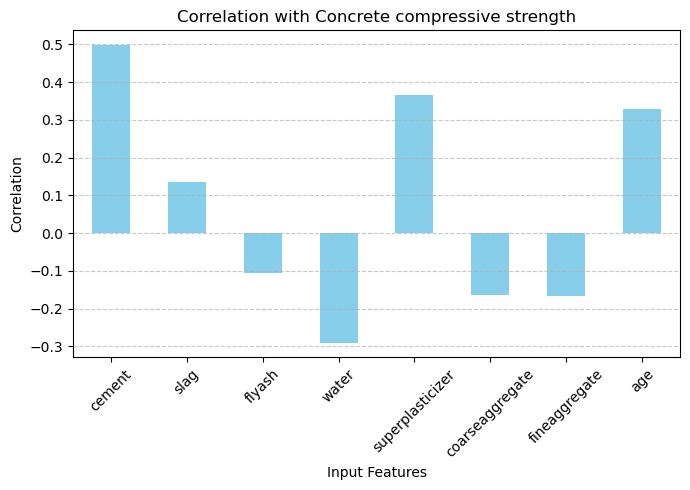

In [2]:
import matplotlib.pyplot as plt

# 计算相关系数
correlation = df_filled.corr()

# 只保留输入特征与目标变量的相关性，排除目标变量自身
target_name = df_filled.columns[-1]
feature_correlation = correlation.loc[correlation.index[:-1], target_name]

# 可视化
plt.figure(figsize=(7, 5))
feature_correlation.plot(kind='bar', color='skyblue')
plt.title('Correlation with Concrete compressive strength')
plt.xlabel('Input Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 主成分分析
PCA 用于分析特征方差结构并评估降维可行性。
本作业仅有 8 个输入特征，最终建模仍采用原始特征，以保留可解释性；PCA 结果保留用于后续高维任务迁移。

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载数据
df = df_filled.copy()

# 分离特征和目标变量
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
feature_names = X.columns.tolist()
target_name = y.name

# 标准化特征后做 PCA 分析
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 保留 90% 的累计方差
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

# 输出 PCA 结果，作为特征分析参考
explained_variance = pca.explained_variance_ratio_
print("各主成分解释方差占比：", np.round(explained_variance, 4))
print("累计解释方差占比：", np.round(explained_variance.cumsum(), 4))
print("保留的主成分数量：", X_pca.shape[1])

# 当前任务本身只有 8 个输入特征，建模阶段保留全部原始特征
selected_features = X.copy()
selected_features[target_name] = y.values

print("用于建模的特征：", feature_names)

各主成分解释方差占比： [0.285  0.177  0.1675 0.1268 0.1189 0.0988]
累计解释方差占比： [0.285  0.462  0.6295 0.7563 0.8752 0.974 ]
保留的主成分数量： 6
用于建模的特征： ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age']


# 神经网络建模
这里采用随机 80%/20% 划分（random_state=42）进行回归建模。
采用多层感知机预测混凝土抗压强度，并以 MSE、RMSE、MAE 及预测散点图评估效果。

使用设备: cuda
Epoch [50/300], Train Loss: 80.7634
Epoch [100/300], Train Loss: 41.2392
Epoch [150/300], Train Loss: 28.8194
Epoch [200/300], Train Loss: 20.8032
Epoch [250/300], Train Loss: 16.7574
Epoch [300/300], Train Loss: 15.0908
Test MSE: 33.8237
Test RMSE: 5.9674
Test MAE: 4.0379


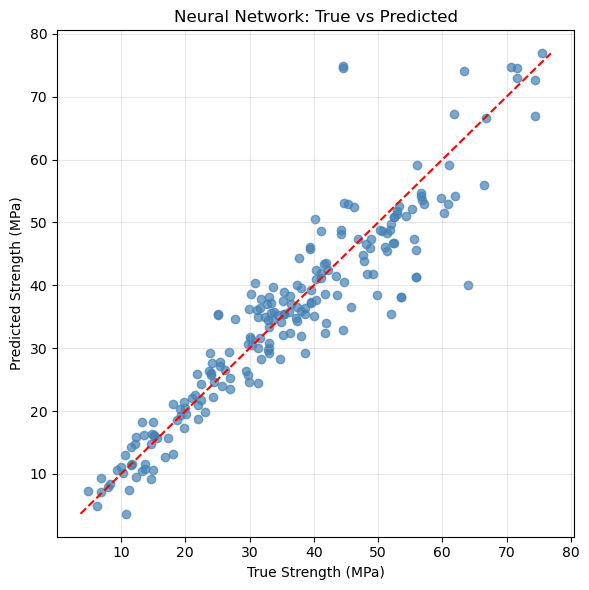

In [6]:
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 固定随机种子，保证结果可复现
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

# 定义自定义 Dataset 类
class ConcreteDataset(Dataset):
    def __init__(self, features, targets):
        self.features = features
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# 加载数据（默认：使用 8 个原始输入特征 + 1 个输出目标）
df = selected_features.copy()
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)

# 备选方案（迁移到高维任务时可启用）：使用 PCA 主成分作为模型输入
## X = X_pca
## y = df.iloc[:, -1].values.reshape(-1, 1)

# 随机划分：80% 训练、20% 测试
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 仅用训练集拟合标准化器，避免数据泄漏
feature_scaler = StandardScaler()
X_train = feature_scaler.fit_transform(X_train)
X_test = feature_scaler.transform(X_test)

# 转换为 tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = ConcreteDataset(X_train, y_train)
test_dataset = ConcreteDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

model = Net(input_size=X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练
num_epochs = 300
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {running_loss / len(train_loader):.4f}')

# 测试评估
model.eval()
total_loss = 0.0
all_predictions = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        total_loss += loss.item()
        all_predictions.append(outputs.cpu())
        all_targets.append(targets.cpu())

predictions = torch.cat(all_predictions, dim=0)
targets = torch.cat(all_targets, dim=0)
test_mse = total_loss / len(test_loader)
test_rmse = torch.sqrt(((predictions - targets) ** 2).mean()).item()
test_mae = torch.mean(torch.abs(predictions - targets)).item()

print(f'Test MSE: {test_mse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')
print(f'Test MAE: {test_mae:.4f}')

# 可视化：测试集真实值 vs 预测值
plt.figure(figsize=(6, 6))
plt.scatter(targets.numpy(), predictions.numpy(), alpha=0.7, color='steelblue')
min_v = min(targets.min().item(), predictions.min().item())
max_v = max(targets.max().item(), predictions.max().item())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
plt.xlabel('True Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Neural Network: True vs Predicted')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 线性回归对照模型
为满足课程建议并形成模型对照，使用相同的数据划分和预处理流程训练线性回归模型。
通过与神经网络的 MSE、RMSE、MAE 对比，判断非线性模型是否带来收益。

Linear Regression Test MSE: 95.9709
Linear Regression Test RMSE: 9.7965
Linear Regression Test MAE: 7.7456


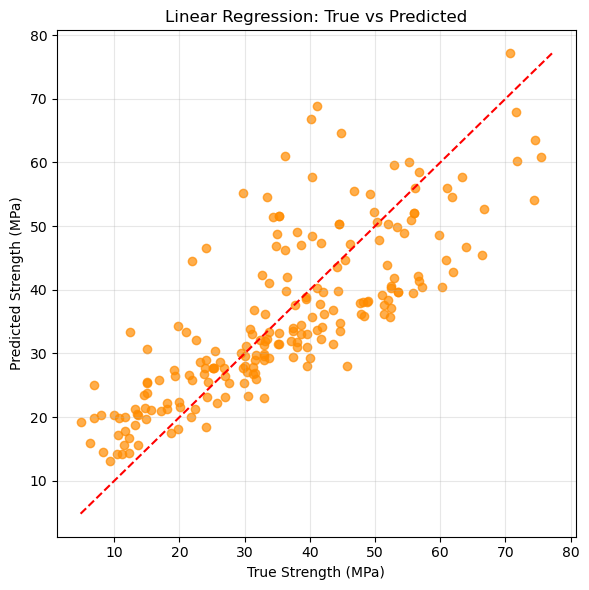

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 与神经网络保持同样的随机划分策略
df_lr = selected_features.copy()
X_lr = df_lr.iloc[:, :-1].values
y_lr = df_lr.iloc[:, -1].values

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, shuffle=True
)

# 与神经网络保持同样的特征标准化策略
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train_lr)
X_test_lr = scaler_lr.transform(X_test_lr)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)

lr_mse = mean_squared_error(y_test_lr, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test_lr, y_pred_lr)

print(f'Linear Regression Test MSE: {lr_mse:.4f}')
print(f'Linear Regression Test RMSE: {lr_rmse:.4f}')
print(f'Linear Regression Test MAE: {lr_mae:.4f}')

plt.figure(figsize=(6, 6))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.7, color='darkorange')
min_v_lr = min(np.min(y_test_lr), np.min(y_pred_lr))
max_v_lr = max(np.max(y_test_lr), np.max(y_pred_lr))
plt.plot([min_v_lr, max_v_lr], [min_v_lr, max_v_lr], 'r--', linewidth=1.5)
plt.xlabel('True Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Linear Regression: True vs Predicted')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 结果解读
1. **评价指标含义**：
- **MSE（Mean Squared Error）**：预测误差平方的平均值，对大误差更敏感，越小越好。
- **RMSE（Root Mean Squared Error）**：MSE 开平方后得到，与目标变量（MPa）同量纲，便于直观理解误差大小，越小越好。
- **MAE（Mean Absolute Error）**：预测误差绝对值的平均值，反映平均偏差水平，越小越好。

2. **结合散点图的偏差分析**：
- 理想情况下，散点应尽量贴近红色虚线 $y=x$，表示预测值接近真实值。
- 神经网络散点整体更紧密地分布在 $y=x$ 附近，说明整体拟合效果更好。
- 在线性回归图中，中高强度区间（约 40 MPa 以上）离散更明显，部分点偏离虚线较大，说明该区间误差更大。
- 两个模型在极端高强度样本上都存在一定偏差，但神经网络的整体偏差更小。

3. **最终结论**：
在当前随机划分（random_state=42）下，神经网络在 MSE、RMSE、MAE 三项指标上均优于线性回归，说明该任务中引入非线性建模能够带来更好的预测性能。